# Fase 11-13: Baselines, modelado inicial y validación

## 11. Baselines

Para forecasting, los baselines obligatorios son:

- **Naive** (último valor): `y_pred = gold_spot(t)` -> a todos los horizontes.
- **Naive estacional** (mismo día de la semana anterior, h=5) / valor de hace 21 días (h=21).
- **Media móvil** 21 días.
- **ARIMA** (auto_arima-ish con statsmodels) como baseline estadístico clásico.

## 12. Modelado inicial

Secuencia de complejidad:

1. Ridge (lineal regularizado) sobre features estándar.
2. Random Forest (no lineal).
3. XGBoost / LightGBM / CatBoost (boosting).
4. MLP (deep learning básico).

## 13. Validación

- TimeSeriesSplit(5, gap=21) sobre train+val; preprocesador dentro de cada fold.
- Métricas: MAE, RMSE, sMAPE, R², Directional Accuracy.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de datos y configuración de CV.

Cargamos las features (con warm-up eliminado), la lista de features
seleccionadas (fase 10) y el TimeSeriesSplit. También unimos train+val
para la CV (test permanece bloqueado).

In [2]:
import json

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from src.config import get_config
from src.data.split import (drop_warmup, get_temporal_splitter, temporal_split)
from src.evaluation.metrics import regression_metrics
from src.models.pipeline import fit_preprocessor
from src.utils import path_from_root

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
train_val = pd.concat([parts["train"], parts["val"]]) \
    .sort_values("date").reset_index(drop=True)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)

h = cfg["target"]["primary_horizon"]
tscv = get_temporal_splitter(cfg)
print(f"train+val: {len(train_val)} filas | features: {len(sel_cols)} | horizonte: {h}")

train+val: 5739 filas | features: 110 | horizonte: 1


Función de evaluación con CV temporal.

`cv_evaluate` entrena el modelo en cada fold (con preprocesador ajustado
solo con el train del fold) y devuelve las métricas medias. Así medimos
la capacidad de generalización temporal sin tocar test.

In [3]:
def cv_evaluate(model, label, horizon=h):
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(train_val)):
        tr, va = train_val.iloc[tr_idx], train_val.iloc[va_idx]
        pp = fit_preprocessor(tr[sel_cols].to_numpy(dtype=np.float64))
        Xtr = pp.transform(tr[sel_cols].to_numpy(dtype=np.float64))
        Xva = pp.transform(va[sel_cols].to_numpy(dtype=np.float64))
        m = model.__class__(**model.get_params()) if hasattr(model, "get_params") else model
        m.fit(Xtr, tr[f"target_{h}"].to_numpy())
        yp = m.predict(Xva)
        rows.append(regression_metrics(va[f"target_{h}"].to_numpy(), yp, h))
    res = pd.DataFrame(rows)
    print(f"[CV] {label:20s} MAE={res['mae'].mean():8.2f} ±{res['mae'].std():6.2f} | "
          f"RMSE={res['rmse'].mean():8.2f} | sMAPE={res['smape'].mean():5.2f}% | "
          f"DA={res['directional_accuracy'].mean():5.1f}%")
    return res

Baseline naive (último valor conocido).

Predice que el precio no cambia: y_pred = último gold_spot del train de
cada fold. Es el baseline mínimo que cualquier modelo debe superar.

In [4]:
def baseline_naive(train_val, h):
    rows = []
    for tr_idx, va_idx in tscv.split(train_val):
        va = train_val.iloc[va_idx]
        last = train_val.iloc[tr_idx]["gold_spot"].iloc[-1]
        yp = np.full(len(va), last)
        rows.append(regression_metrics(va[f"target_{h}"].to_numpy(), yp, h))
    res = pd.DataFrame(rows)
    print(f"[CV] {'Naive (último valor)':20s} MAE={res['mae'].mean():8.2f} | "
          f"RMSE={res['rmse'].mean():8.2f} | sMAPE={res['smape'].mean():5.2f}%")
    return res

naive_res = baseline_naive(train_val, h)

[CV] Naive (último valor) MAE=  287.22 | RMSE=  336.51 | sMAPE=25.68%


Modelos iniciales: Ridge, RandomForest y XGBoost.

Siguiendo la secuencia de complejidad del índice (lineal -> no lineal ->
boosting), evaluamos tres familias representativas. Los resultados de CV
orientan qué familias merecen tuning en la fase 14.

In [5]:
ridge_res = cv_evaluate(Ridge(alpha=1.0), "Ridge")
rf_res = cv_evaluate(RandomForestRegressor(n_estimators=200, max_depth=12,
                                           min_samples_leaf=5, n_jobs=-1,
                                           random_state=42), "RandomForest")
xgb_res = cv_evaluate(XGBRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=5, subsample=0.85,
                                   colsample_bytree=0.7, random_state=42,
                                   n_jobs=-1), "XGBoost")

[CV] Ridge                MAE=  107.10 ± 46.45 | RMSE=  128.87 | sMAPE=10.24% | DA= 48.3%


[CV] RandomForest         MAE=  228.35 ±110.69 | RMSE=  268.06 | sMAPE=22.46% | DA= 49.0%


[CV] XGBoost              MAE=  216.45 ±107.57 | RMSE=  250.67 | sMAPE=21.83% | DA= 48.2%


Resumen comparativo de CV y guardado.

Tabla con las métricas medias por modelo. Se guarda en CSV para el informe.
Este resultado (Ridge muy por delante de los árboles) es un hallazgo clave:
los ensembles no extrapolan niveles no estacionarios.

In [6]:
summary = pd.concat([
    naive_res.mean().rename("Naive"),
    ridge_res.mean().rename("Ridge"),
    rf_res.mean().rename("RandomForest"),
    xgb_res.mean().rename("XGBoost"),
], axis=1).T[["mae", "rmse", "smape", "directional_accuracy"]]
print(summary.round(3).to_string())
summary.to_csv(path_from_root("reports", "cv_baselines_initial.csv"))

                  mae     rmse   smape  directional_accuracy
Naive         287.225  336.512  25.681                 0.377
Ridge         107.104  128.874  10.242                48.272
RandomForest  228.350  268.065  22.461                49.005
XGBoost       216.455  250.673  21.833                48.168


Visualización comparativa de baselines.

Gráfico de barras con MAE y sMAPE por modelo en CV. Facilita la lectura
del hallazgo: el modelo lineal supera claramente a los árboles.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\cv_baselines.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/cv_baselines.png')

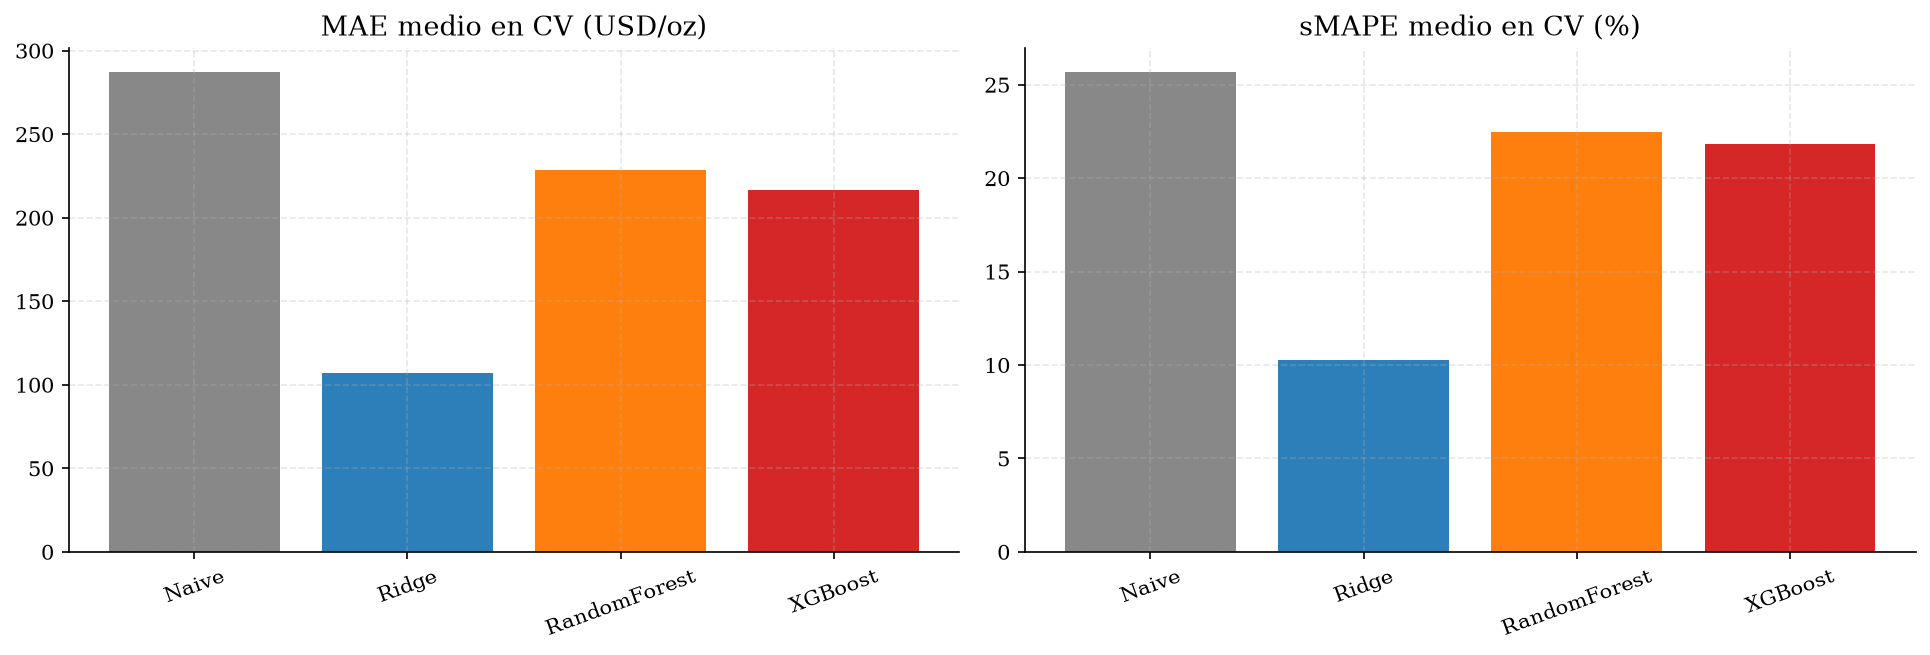

In [7]:
import matplotlib.pyplot as plt

from src.utils import save_fig

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = list(summary.index)
axes[0].bar(labels, summary["mae"], color=["#888", "#2c7fb8", "#ff7f0e", "#d62728"])
axes[0].set_title("MAE medio en CV (USD/oz)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(labels, summary["smape"], color=["#888", "#2c7fb8", "#ff7f0e", "#d62728"])
axes[1].set_title("sMAPE medio en CV (%)")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
save_fig(fig, "cv_baselines.png")